# Deteccion de Muelas del Juicio — Exp8: DeepGA (Neural Architecture Search)

**Materia:** Redes Neuronales  
**Docente:** Ing. Pablo Marinozi  
**Dataset:** DENTEX — MICCAI 2023  
**Repo:** https://github.com/JulianOliveraBalls/dentex-wisdom-teeth

---

## ¿Que es DeepGA?

**DeepGA** es un algoritmo de **Busqueda de Arquitecturas Neuronales** (Neural Architecture Search, NAS)  
propuesto por Vargas-Hakim et al. (GECCO 2021) que utiliza un **Algoritmo Genetico (AG)**  
para encontrar automaticamente la mejor arquitectura de red neuronal convolucional para una tarea dada.

> Vargas-Hakim, G.A., Mezura-Montes, E., & Acosta-Mesa, H.G. (2021).  
> *Hybrid encodings for neuroevolution of convolutional neural networks: a case study.*  
> GECCO 2021. DOI: [10.1145/3449726.3463133](https://doi.org/10.1145/3449726.3463133)  
> Repo original: https://github.com/GustavoVargasHakim/DeepGA

Este notebook fue adaptado del taller *"Experiencias con Evolutionary Neural Architecture Search"*  
presentado por Jesus Arnulfo Barradas Palmeros (WCCI 2026).

---

## ¿Por que usarlo en nuestro proyecto?

En los experimentos Exp1-7 usamos **YOLOv8s** con arquitectura fija preentrenada en COCO.  
DeepGA representa un enfoque completamente distinto: en vez de usar una arquitectura diseñada  
por humanos, **evoluciona la arquitectura automaticamente** usando principios de seleccion natural.

Esto nos permite responder:  
> *¿Una arquitectura evolucionada especificamente para clasificar muelas del juicio  
> supera a una arquitectura disenada por humanos (YOLOv8)?*

---

## Diferencias clave con Exp1-7

| Aspecto | Exp1-7 (YOLOv8) | Exp8 (DeepGA) |
|---------|-----------------|----------------|
| Arquitectura | Fija, disenada por humanos | Evolucionada automaticamente por AG |
| Tarea | Deteccion de objetos (bbox + clase) | Clasificacion de crops (erupted/impacted) |
| Preentrenamiento | COCO (80 clases) | Desde cero sobre DENTEX |
| Hiperparametros | Manuales | Buscados por el AG |
| Conexiones skip | Fijas (FPN de YOLO) | Evolucionadas (segundo nivel del encoding) |

---

## Flujo del experimento

```
Imagen completa DENTEX
       ↓
Extraer crops de muelas del juicio (usando bboxes del JSON)
       ↓
Dataset de clasificacion: erupted vs impacted (128x128 px)
       ↓
DeepGA busca la mejor arquitectura CNN:
  - Poblacion inicial de 10 redes aleatorias
  - Cada red se entrena 3 epochs y se evalua
  - Seleccion, crossover y mutacion por 10 generaciones
  - Fitness = accuracy * (1-w) + complejidad_normalizada * w
       ↓
Mejor arquitectura encontrada
       ↓
Reentrenamiento completo de la mejor red (20 epochs)
       ↓
Comparacion con Exp1-7
```

---

## Estructura del notebook

| Seccion | Contenido |
|---------|-----------|
| 1 | Setup y descarga del dataset |
| 2 | Preparacion del dataset de clasificacion (crops) |
| 3 | Encoding: representacion genetica de arquitecturas CNN |
| 4 | Decoding: construccion de la red PyTorch desde el encoding |
| 5 | Operadores geneticos: crossover, mutacion, seleccion |
| 6 | Funcion de fitness y entrenamiento de individuos |
| 7 | Bucle principal de DeepGA |
| 8 | Reentrenamiento de la mejor arquitectura |
| 9 | Comparacion con Exp1-7 |

deepga_nas_diagram.svg

## Seccion 1 — Setup

In [1]:
# Celda 0 — Instalar dependencias (correr y reiniciar sesion)
!pip install torch==2.3.0 torchvision==0.18.0 --upgrade -q
!pip install huggingface_hub scikit-learn -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 779.1/779.1 MB 2.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.0/7.0 MB 41.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 410.6/410.6 MB 4.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 14.1/14.1 MB 103.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.7/23.7 MB 82.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 823.6/823.6 kB 54.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 731.7/731.7 MB 1.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 121.6/121.6 MB 7.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.5/56.5 MB 17.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 124.2/124.2 MB 7.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 196.0/196.0 MB 5.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 176.2/176.2 MB 6.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 

In [2]:
import subprocess, sys, json, shutil, random, warnings, gc, math, timeit
from pathlib import Path
from collections import Counter, defaultdict
from copy import deepcopy
warnings.filterwarnings('ignore')

try:
    import google.colab
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

print(f'Entorno: {"Google Colab" if IN_COLAB else "Local"}')

BASE_DIR    = Path('/content') if IN_COLAB else Path.cwd().parent
DATA_DIR    = BASE_DIR / 'data'
DATASET_DIR = DATA_DIR / 'raw' / 'dentex_raw'
YOLO_DIR    = DATA_DIR / 'processed' / 'yolo_dataset'
CROPS_DIR   = DATA_DIR / 'processed' / 'crops'        # dataset de clasificacion
DEEPGA_DIR  = DATA_DIR / 'outputs' / 'deepga'          # resultados del NAS
OUTPUTS_DIR = DATA_DIR / 'outputs'

for d in [CROPS_DIR/'train', CROPS_DIR/'val', CROPS_DIR/'test', DEEPGA_DIR, OUTPUTS_DIR]:
    d.mkdir(parents=True, exist_ok=True)

Entorno: Google Colab


In [3]:
import torch
import torch.nn as nn
from torch import optim
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
import torchvision.transforms as T
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from PIL import Image
from sklearn.model_selection import train_test_split

random.seed(42)
np.random.seed(42)
torch.manual_seed(42)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'PyTorch: {torch.__version__}')
print(f'Device:  {device}')
if torch.cuda.is_available():
    print(f'GPU:     {torch.cuda.get_device_name(0)}')

def is_real_file(p):
    try:
        return p.resolve().exists() and p.stat().st_size > 0
    except (OSError, FileNotFoundError):
        return False

def log(msg, level='INFO'):
    icons = {'INFO':'[INFO]','OK':'[OK]  ','WARN':'[WARN]','ERR':'[ERR] ','DATA':'[DATA]'}
    print(f'{icons.get(level,"[INFO]")} {msg}')

PyTorch: 2.3.0+cu121
Device:  cuda
GPU:     Tesla T4


In [4]:
# Descargar dataset si no existe
from huggingface_hub import hf_hub_download
import zipfile

json_files = [f for f in DATASET_DIR.rglob('*.json') if is_real_file(f)] if DATASET_DIR.exists() else []
train_ok = any('disease' in f.name.lower() for f in json_files)

if train_ok:
    log(f'Dataset encontrado', 'OK')
else:
    log('Descargando DENTEX desde HuggingFace...', 'WARN')
    for fname, desc in [('DENTEX/training_data.zip','training (~3GB)'),
                        ('DENTEX/validation_data.zip','validation')]:
        zip_path = hf_hub_download(repo_id='ibrahimhamamci/DENTEX',
                                   repo_type='dataset', filename=fname,
                                   local_dir=str(DATASET_DIR))
        with zipfile.ZipFile(zip_path,'r') as z:
            z.extractall(str(DATASET_DIR/'DENTEX'))
        log(f'{desc} listo', 'OK')
    json_files = [f for f in DATASET_DIR.rglob('*.json') if is_real_file(f)]

TRAIN_JSON = next((j for j in json_files if 'disease' in j.name.lower()), None)
IMG_DIR_C  = next((c for c in [TRAIN_JSON.parent/'xrays', TRAIN_JSON.parent.parent/'xrays']
                   if c.exists()), TRAIN_JSON.parent/'xrays')

with open(TRAIN_JSON) as f:
    data_c = json.load(f)
id_to_image_c = {img['id']: img for img in data_c['images']}

wisdom_c = defaultdict(list)
for ann in data_c['annotations']:
    if ann.get('category_id_2') == 7:
        wisdom_c[ann['image_id']].append(ann)

log(f'JSON: {TRAIN_JSON.name}', 'OK')
log(f'Imagenes: {len(data_c["images"])}  |  Con muela: {len(wisdom_c)}', 'DATA')

[WARN] Descargando DENTEX desde HuggingFace...


DENTEX/training_data.zip:   0%|          | 0.00/10.9G [00:00<?, ?B/s]

[OK]   training (~3GB) listo


DENTEX/validation_data.zip:   0%|          | 0.00/150M [00:00<?, ?B/s]

[OK]   validation listo
[OK]   JSON: train_quadrant_enumeration_disease.json
[DATA] Imagenes: 705  |  Con muela: 440


## Seccion 2 — Preparacion del dataset de clasificacion (crops)

DeepGA trabaja con **clasificacion de imagenes**, no con deteccion de objetos.  
Para adaptarlo a nuestro problema, extraemos crops de cada muela del juicio del JSON  
y los usamos como dataset de clasificacion binaria: **erupted (0) vs impacted (1)**.

**Tamano de crop:** 128x128 px con padding de 20px alrededor del bounding box.  
Es suficientemente grande para capturar contexto anatómico y suficientemente pequeño  
para que el AG pueda entrenar muchas arquitecturas en tiempo razonable.

In [5]:
def extraer_crops(yolo_split_dir_or_none=None):
    """
    Extrae crops de muelas del juicio del JSON original.
    Cada crop es una imagen de 128x128 con la muela centrada.
    Devuelve listas de (pil_crop, label, image_id, ann_id).
    """
    CROP_SIZE = 128
    PAD       = 20
    samples   = []

    for img_id, anns in wisdom_c.items():
        info     = id_to_image_c[img_id]
        img_path = IMG_DIR_C / Path(info['file_name']).name
        if not is_real_file(img_path): continue

        pil  = Image.open(img_path).convert('L')  # escala de grises
        W, H = pil.size

        for ann in anns:
            x, y, bw, bh = ann['bbox']
            # Expandir con padding
            x1 = max(0, int(x - PAD))
            y1 = max(0, int(y - PAD))
            x2 = min(W, int(x + bw + PAD))
            y2 = min(H, int(y + bh + PAD))
            crop = pil.crop((x1, y1, x2, y2)).resize((CROP_SIZE, CROP_SIZE))
            label = 1 if ann.get('category_id_3') == 0 else 0
            samples.append((crop, label, img_id, ann['id']))

    return samples

# Generar crops si no existen
crops_train = list(CROPS_DIR.glob('train/*.png'))
if len(crops_train) > 0:
    log(f'Crops encontrados: {len(list(CROPS_DIR.rglob("*.png")))} total', 'OK')
else:
    log('Generando crops...', 'INFO')
    all_samples = extraer_crops()

    # Split estratificado por imagen (no por crop, para evitar data leakage)
    img_ids = list(wisdom_c.keys())
    labels  = [1 if any(a.get('category_id_3')==0 for a in wisdom_c[i]) else 0 for i in img_ids]

    ids_tr, ids_tmp, _, y_tmp = train_test_split(
        img_ids, labels, test_size=0.30, stratify=labels, random_state=42)
    ids_val, ids_te, _, _ = train_test_split(
        ids_tmp, y_tmp, test_size=0.833, stratify=y_tmp, random_state=42)

    split_map = {i:'train' for i in ids_tr}
    split_map.update({i:'val' for i in ids_val})
    split_map.update({i:'test' for i in ids_te})

    counts = Counter()
    for crop, label, img_id, ann_id in all_samples:
        split = split_map.get(img_id, 'train')
        cls_name = 'impacted' if label == 1 else 'erupted'
        save_dir = CROPS_DIR / split / cls_name
        save_dir.mkdir(parents=True, exist_ok=True)
        crop.save(str(save_dir / f'{img_id}_{ann_id}.png'))
        counts[(split, cls_name)] += 1

    log('Crops generados:', 'OK')
    for (split, cls), n in sorted(counts.items()):
        log(f'  {split}/{cls}: {n}', 'DATA')

# Mostrar estadisticas
log('Estadisticas del dataset de crops:', 'DATA')
total_crops = 0
for split in ['train', 'val', 'test']:
    eru = len(list((CROPS_DIR/split/'erupted').glob('*.png')))
    imp = len(list((CROPS_DIR/split/'impacted').glob('*.png')))
    total_crops += eru + imp
    log(f'  {split:5s}: {eru+imp} crops (erupted={eru}, impacted={imp})', 'DATA')
log(f'  TOTAL: {total_crops}', 'DATA')

[INFO] Generando crops...
[OK]   Crops generados:
[DATA]   test/erupted: 84
[DATA]   test/impacted: 131
[DATA]   train/erupted: 227
[DATA]   train/impacted: 443
[DATA]   val/erupted: 17
[DATA]   val/impacted: 30
[DATA] Estadisticas del dataset de crops:
[DATA]   train: 670 crops (erupted=227, impacted=443)
[DATA]   val  : 47 crops (erupted=17, impacted=30)
[DATA]   test : 215 crops (erupted=84, impacted=131)
[DATA]   TOTAL: 932


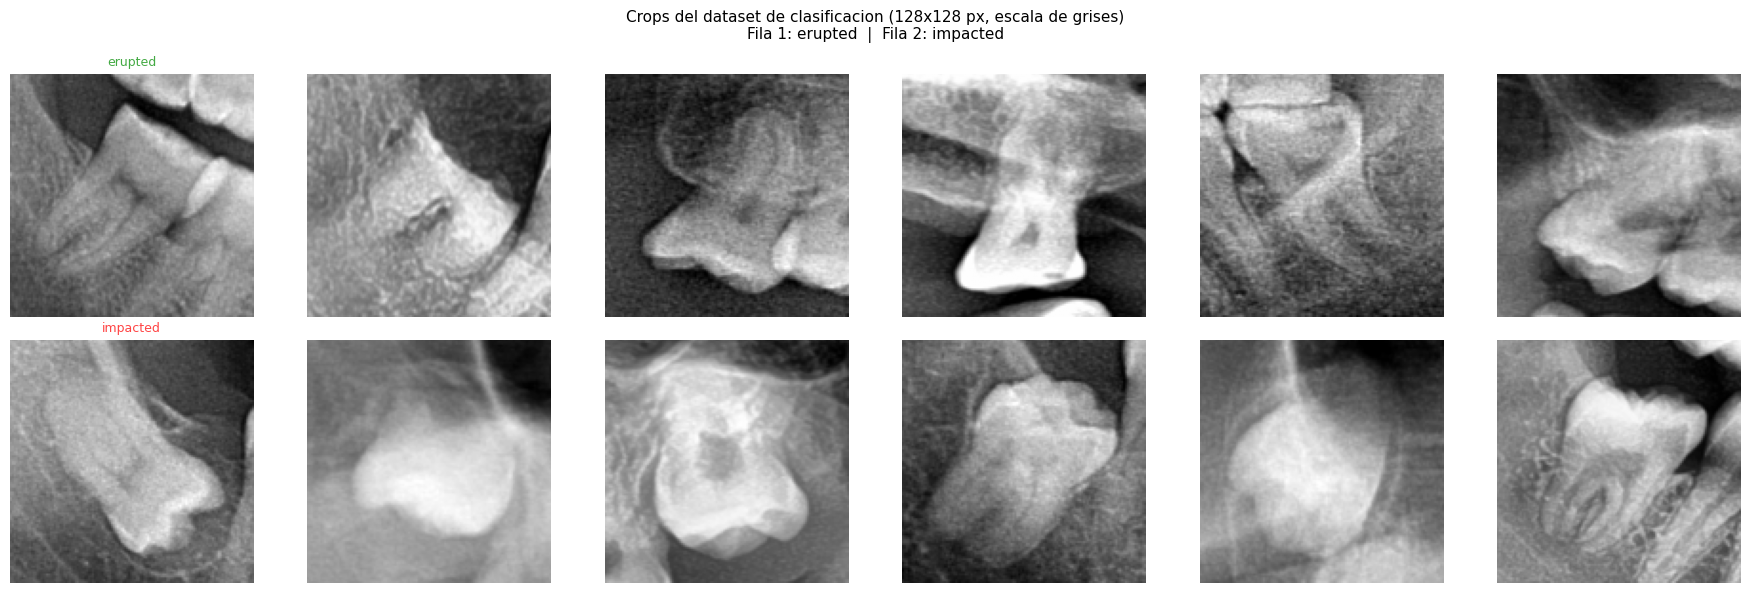

[OK]   Guardado: deepga_crops_ejemplos.png


In [6]:
# Visualizar ejemplos de crops
fig, axes = plt.subplots(2, 6, figsize=(18, 6))

for row, cls_name in enumerate(['erupted', 'impacted']):
    imgs = list((CROPS_DIR/'train'/cls_name).glob('*.png'))
    samples_vis = random.sample(imgs, min(6, len(imgs)))
    for col, img_path in enumerate(samples_vis):
        ax = axes[row][col]
        ax.imshow(np.array(Image.open(img_path)), cmap='gray')
        ax.set_title(cls_name if col==0 else '', fontsize=9,
                     color='#FF4444' if cls_name=='impacted' else '#44AA44')
        ax.axis('off')

plt.suptitle('Crops del dataset de clasificacion (128x128 px, escala de grises)\n'
             'Fila 1: erupted  |  Fila 2: impacted', fontsize=11)
plt.tight_layout()
plt.savefig(str(OUTPUTS_DIR/'deepga_crops_ejemplos.png'), dpi=100, bbox_inches='tight')
plt.show()
log('Guardado: deepga_crops_ejemplos.png', 'OK')

In [7]:
# Dataset y DataLoaders para DeepGA
CROP_SIZE  = 128
BATCH_SIZE = 32

transform_train = T.Compose([
    T.Grayscale(num_output_channels=1),
    T.Resize((CROP_SIZE, CROP_SIZE)),
    T.RandomHorizontalFlip(p=0.5),
    T.ColorJitter(brightness=0.2, contrast=0.2),
    T.ToTensor(),
    T.Normalize(mean=[0.5], std=[0.5])   # normalizacion para canal unico
])

transform_eval = T.Compose([
    T.Grayscale(num_output_channels=1),
    T.Resize((CROP_SIZE, CROP_SIZE)),
    T.ToTensor(),
    T.Normalize(mean=[0.5], std=[0.5])
])

from torchvision.datasets import ImageFolder

ds_train_ga = ImageFolder(str(CROPS_DIR/'train'), transform=transform_train)
ds_val_ga   = ImageFolder(str(CROPS_DIR/'val'),   transform=transform_eval)
ds_test_ga  = ImageFolder(str(CROPS_DIR/'test'),  transform=transform_eval)

# Weighted sampler para balancear clases en train
class_counts = Counter(ds_train_ga.targets)
weights = [1.0 / class_counts[t] for t in ds_train_ga.targets]
sampler = WeightedRandomSampler(weights, num_samples=len(weights), replacement=True)

dl_train_ga = DataLoader(ds_train_ga, batch_size=BATCH_SIZE, sampler=sampler,  num_workers=2)
dl_val_ga   = DataLoader(ds_val_ga,   batch_size=BATCH_SIZE, shuffle=False, num_workers=2)
dl_test_ga  = DataLoader(ds_test_ga,  batch_size=BATCH_SIZE, shuffle=False, num_workers=2)

log(f'DataLoaders de clasificacion:', 'OK')
log(f'  train: {len(ds_train_ga)} crops | clases: {dict(class_counts)}', 'DATA')
log(f'  val:   {len(ds_val_ga)} crops', 'DATA')
log(f'  test:  {len(ds_test_ga)} crops', 'DATA')
log(f'  clases: {ds_train_ga.classes}  (0=erupted, 1=impacted)', 'DATA')

[OK]   DataLoaders de clasificacion:
[DATA]   train: 670 crops | clases: {0: 227, 1: 443}
[DATA]   val:   47 crops
[DATA]   test:  215 crops
[DATA]   clases: ['erupted', 'impacted']  (0=erupted, 1=impacted)


## Seccion 3 — Encoding: representacion genetica de arquitecturas CNN

DeepGA usa una **codificacion hibrida de dos niveles** para representar arquitecturas CNN:

### Primer nivel — bloques de capas
Lista de bloques que describe cada capa de la red:
- **Bloque Conv:** `{tipo, n_filtros, kernel_size, pooling, pool_size}`
- **Bloque FC:** `{tipo, n_neuronas}`

Ejemplo: `[Conv(32,3,max,2), Conv(64,5,off), FC(128), FC(64)]`

### Segundo nivel — conexiones skip
Vector binario que indica si hay conexiones de salto (skip connections) entre capas convolucionales.  
Inspirado en DenseNet/ResNet pero evolucionado automaticamente.

Por ejemplo, con 4 capas conv, el segundo nivel tiene `0+1+2+3=6` bits:
```
Capa 3 puede conectar con capas 1,2    → 2 bits
Capa 4 puede conectar con capas 1,2,3  → 3 bits
```

Si el bit es 1, la salida de esa capa anterior se concatena (cat) con la entrada actual,  
permitiendo que la red acceda a features de distintos niveles de abstraccion.

In [8]:
# Hiperparametros del espacio de busqueda
FSIZES   = [3, 5]              # kernel sizes de conv
NFILTERS = [16, 32, 64, 128]   # numero de filtros
PSIZES   = [2, 3]              # tamanos de pooling
NEURONS  = [32, 64, 128, 256]  # neuronas en capas FC

class Encoding:
    """
    Representacion genetica de una arquitectura CNN.

    Atributos:
        n_conv      (int):  numero de capas convolucionales
        n_full      (int):  numero de capas fully connected
        first_level (list): descripcion de cada capa [conv o fc]
        second_level(list): bits de conexiones skip entre capas conv
    """
    def __init__(self, min_conv, max_conv, min_full, max_full):
        self.n_conv = random.randint(min_conv, max_conv)
        self.n_full = random.randint(min_full, max_full)

        # Primer nivel: bloques de capas
        self.first_level = []
        for _ in range(self.n_conv):
            self.first_level.append({
                'type':     'conv',
                'nfilters': random.choice(NFILTERS),
                'fsize':    random.choice(FSIZES),
                'pool':     random.choice(['max', 'avg', 'off']),
                'psize':    random.choice(PSIZES)
            })
        for _ in range(self.n_full):
            self.first_level.append({
                'type':    'fc',
                'neurons': random.choice(NEURONS)
            })

        # Segundo nivel: bits de skip connections
        # La capa i puede conectar con las i-1 capas anteriores
        # Total bits = 0 + 1 + 2 + ... + (n_conv-2) = (n_conv-1)*(n_conv-2)/2
        self.second_level = []
        prev = -1
        for i in range(self.n_conv):
            if prev < 1:
                prev += 1
            if prev >= 1:
                for _ in range(prev - 1):
                    self.second_level.append(random.choice([0, 1]))
                prev += 1

def print_encoding(enc):
    """Imprime el encoding de forma legible."""
    print('ARQUITECTURA EVOLUCIONADA')
    print('-' * 45)
    conv_c, fc_c = 1, 1
    for layer in enc.first_level:
        if layer['type'] == 'conv':
            pool_str = f'{layer["pool"]} pool (k={layer["psize"]})' if layer['pool'] != 'off' else 'sin pooling'
            print(f'  [Conv {conv_c}] {layer["nfilters"]} filtros | kernel={layer["fsize"]} | {pool_str}')
            conv_c += 1
        elif layer['type'] == 'fc':
            if fc_c == 1: print()
            print(f'  [FC {fc_c}]   {layer["neurons"]} neuronas')
            fc_c += 1
    print('-' * 45)
    print(f'  Skip connections: {enc.second_level}')
    print(f'  Total capas: {enc.n_conv} conv + {enc.n_full} FC')

# Ejemplo de encoding aleatorio
log('Ejemplo de encoding aleatorio:', 'INFO')
enc_ej = Encoding(2, 4, 1, 2)
print_encoding(enc_ej)

[INFO] Ejemplo de encoding aleatorio:
ARQUITECTURA EVOLUCIONADA
---------------------------------------------
  [Conv 1] 128 filtros | kernel=3 | max pool (k=2)
  [Conv 2] 32 filtros | kernel=3 | sin pooling
  [Conv 3] 32 filtros | kernel=5 | max pool (k=3)
  [Conv 4] 64 filtros | kernel=3 | max pool (k=3)

  [FC 1]   128 neuronas
---------------------------------------------
  Skip connections: [1, 0, 0]
  Total capas: 4 conv + 1 FC


## Seccion 4 — Decoding: construccion de la red PyTorch desde el encoding

El **decoding** traduce el encoding genetico a una red PyTorch ejecutable.  
Calcula las dimensiones de salida de cada capa teniendo en cuenta el tamano de entrada  
y las conexiones skip (que cambian el numero de canales de entrada por concatenacion).

In [30]:
def conv_out_size(W, K):
    """Tamano de salida de una conv con padding=1."""
    return W - K + 3

def pool_out_size(W, K):
    """Tamano de salida de un pooling con stride=2."""
    return math.floor((W - K) / 2) + 1

def decoding(encoding, img_size=128, img_chann=1, no_classes=2):
    n_conv       = encoding.n_conv
    n_full       = encoding.n_full
    first_level  = encoding.first_level
    second_level = encoding.second_level

    features    = []
    classifier  = []
    in_channels = img_chann
    out_size    = img_size
    prev        = -1
    pos         = 0
    o_sizes     = []
    skip_map    = {}

    for i in range(n_conv):
        layer    = first_level[i]
        nfilters = layer['nfilters']
        fsize    = min(layer['fsize'], max(1, out_size - 1))
        pooltype = layer['pool'] if out_size >= 2 else 'off'
        pad      = 1

        active_skips = []
        if i >= 2:
            connections = second_level[pos:pos + prev]
            for c, bit in enumerate(connections):
                if bit == 1:
                    in_channels += o_sizes[c][1]
                    active_skips.append(c)
        skip_map[i] = active_skips

        psize = layer['psize']
        if pooltype == 'off':
            op = [nn.Conv2d(in_channels, nfilters, fsize, padding=pad),
                  nn.BatchNorm2d(nfilters), nn.ReLU(inplace=True)]
            out_size = conv_out_size(out_size, fsize)
        else:
            psize = min(psize, max(1, out_size - 1))
            pool_layer = nn.MaxPool2d(psize, stride=2) if pooltype == 'max' else nn.AvgPool2d(psize, stride=2)
            op = [nn.Conv2d(in_channels, nfilters, fsize, padding=pad),
                  nn.BatchNorm2d(nfilters), nn.ReLU(inplace=True), pool_layer]
            out_size = conv_out_size(out_size, fsize)
            out_size = pool_out_size(out_size, psize)

        in_channels = nfilters
        o_sizes.append([out_size, in_channels])
        features.append(op)

        if i >= 1:
            pos += prev
        prev = max(prev + 1, 1)

    in_size = max(1, out_size) * max(1, out_size) * in_channels
    for i in range(n_conv, n_conv + n_full):
        n_neurons = first_level[i]['neurons']
        classifier += [nn.Linear(in_size, n_neurons), nn.ReLU(inplace=True)]
        in_size = n_neurons

    classifier += [nn.Linear(in_size, no_classes)]
    return features, classifier, o_sizes, skip_map


class CNN(nn.Module):
    """
    Red neuronal convolucional construida a partir de un encoding DeepGA.
    Soporta skip connections entre capas convolucionales (concatenacion).
    """
    def __init__(self, encoding, features, classifier, sizes, skip_map):
        super(CNN, self).__init__()
        self.features   = features
        self.skip_map   = skip_map
        self.sizes      = sizes
        self.classifier = nn.Sequential(*classifier)

        for m in self.modules():
            if isinstance(m, nn.Conv2d):
                nn.init.kaiming_normal_(m.weight, mode='fan_in', nonlinearity='relu')
                if m.bias is not None: nn.init.zeros_(m.bias)
            elif isinstance(m, nn.Linear):
                nn.init.kaiming_normal_(m.weight, mode='fan_in', nonlinearity='relu')
                if m.bias is not None: nn.init.zeros_(m.bias)

    def forward(self, x):
        dev     = x.device
        outputs = {}

        for i in range(len(self.features)):
            if i >= 2:
                for c in self.skip_map[i]:
                    skip_size = self.sizes[c][0]
                    req_size  = x.shape[2]
                    if skip_size > req_size:
                        x2 = nn.MaxPool2d(skip_size - req_size + 1, stride=1).to(dev)(outputs[c])
                    elif skip_size == req_size:
                        x2 = outputs[c]
                    else:
                        diff = req_size - skip_size
                        pad  = (diff // 2, diff - diff // 2, diff // 2, diff - diff // 2)
                        x2 = nn.ZeroPad2d(pad).to(dev)(outputs[c])
                    x = torch.cat((x, x2), dim=1)

            x = nn.Sequential(*self.features[i]).to(dev)(x)
            outputs[i] = x

        x = torch.flatten(x, 1)
        return nn.functional.log_softmax(self.classifier(x), dim=1)


log('Encoding, Decoding y CNN definidos', 'OK')

# Verificar que funciona con una imagen de prueba
enc_test    = Encoding(2, 3, 1, 2)
net_test    = decoding(enc_test, img_size=CROP_SIZE, img_chann=1, no_classes=2)
cnn_test    = CNN(enc_test, net_test[0], net_test[1], net_test[2], net_test[3])
dummy_input = torch.zeros(1, 1, CROP_SIZE, CROP_SIZE)
output      = cnn_test(dummy_input)
params      = sum(p.numel() for p in cnn_test.parameters() if p.requires_grad)
log(f'Red de prueba: output shape={tuple(output.shape)}  params={params:,}', 'OK')

[OK]   Encoding, Decoding y CNN definidos
[OK]   Red de prueba: output shape=(1, 2)  params=1,843,298


## Seccion 5 — Operadores geneticos: crossover, mutacion y seleccion

Los tres operadores fundamentales del Algoritmo Genetico:

### Crossover (cruce)
Combina dos arquitecturas parentales para generar dos hijos.  
Opera por separado sobre la parte convolucional, la FC y los bits de skip connections.  
Intercambia la mitad de los bloques entre padres usando punto de corte.

### Mutacion
Con probabilidad `mr`, modifica una arquitectura de una de dos formas:
- **Estructural** (50%): agrega o elimina una capa conv o FC
- **De hiperparametros** (50%): cambia filtros/neuronas de una capa existente y voltea un bit de skip

### Seleccion por torneo
Selecciona el mejor individuo de un subconjunto aleatorio de tamano `t_size`.  
Con probabilidad 0.8 elige el mejor fitness; con 0.2 elige uno al azar (presion selectiva moderada).

In [31]:
def crossover(x, y):
    """
    Cruza dos encodings para generar dos hijos.
    Opera en la parte conv, FC y skip connections por separado.
    """
    x = deepcopy(x)
    y = deepcopy(y)

    def exchange_blocks(xb, yb, xn, yn):
        if xn > yn:
            k = math.floor(yn / 2)
            idx = list(range(xn))
            for i in range(k, yn):
                ix = random.choice(idx); idx.remove(ix)
                xb[ix], yb[i] = yb[i], xb[ix]
        elif yn > xn:
            k = math.floor(xn / 2)
            idx = list(range(yn))
            for i in range(k, xn):
                ix = random.choice(idx); idx.remove(ix)
                yb[ix], xb[i] = xb[i], yb[ix]
        else:
            k = math.floor(xn / 2)
            xb[k:xn], yb[k:yn] = yb[k:yn], xb[k:xn]

    # Cruce de capas conv
    exchange_blocks(x.first_level, y.first_level, x.n_conv, y.n_conv)

    # Cruce de capas FC
    xfc_s = x.n_conv; yfc_s = y.n_conv
    xb_fc = x.first_level[xfc_s:xfc_s+x.n_full]
    yb_fc = y.first_level[yfc_s:yfc_s+y.n_full]
    exchange_blocks(xb_fc, yb_fc, x.n_full, y.n_full)
    x.first_level[xfc_s:xfc_s+x.n_full] = xb_fc
    y.first_level[yfc_s:yfc_s+y.n_full] = yb_fc

    # Cruce de skip connections
    xb, yb = x.second_level, y.second_level
    if len(xb) > 1 and len(yb) > 1:
        k = random.randrange(1, min(len(xb), len(yb)))
        xb[k:], yb[k:] = yb[k:len(xb)], xb[k:len(yb)]

    return x, y


def mutation(x):
    """
    Muta un encoding con dos estrategias:
    - Estructural: agrega/elimina una capa
    - De hiperparametros: cambia valores de una capa existente
    """
    if random.random() < 0.5:
        # Mutacion estructural
        if random.random() > 0.5 and x.n_full > 1:
            # Eliminar una capa FC
            ix = random.randrange(x.n_conv, x.n_conv + x.n_full)
            x.first_level.pop(ix)
            x.n_full -= 1
        else:
            # Agregar una capa conv
            new_layer = {'type': 'conv', 'nfilters': random.choice(NFILTERS),
                         'fsize': random.choice(FSIZES), 'pool': random.choice(['max','avg','off']),
                         'psize': random.choice(PSIZES)}
            ix = random.randrange(0, x.n_conv + 1)
            x.first_level.insert(ix, new_layer)
            x.n_conv += 1
            # Agregar bits de skip para la nueva capa
            if x.n_conv > 2:
                for _ in range(x.n_conv - 2):
                    x.second_level.append(random.choice([0, 1]))
    else:
        # Mutacion de hiperparametros
        if random.random() > 0.5 and x.n_full > 0:
            ix = random.randrange(x.n_conv, x.n_conv + x.n_full)
            x.first_level[ix]['neurons'] = random.choice(NEURONS)
        else:
            ix = random.randrange(x.n_conv)
            x.first_level[ix]['nfilters'] = random.choice(NFILTERS)
            x.first_level[ix]['fsize']    = random.choice(FSIZES)
        # Voltear un bit de skip
        if x.second_level:
            k = random.randrange(len(x.second_level))
            x.second_level[k] = 1 - x.second_level[k]


def seleccion_torneo(poblacion, t_size, estilo='max'):
    """
    Seleccion estocástica por torneo.
    Con prob 0.8 elige el mejor fitness; con 0.2 uno aleatorio.
    """
    torneo = random.sample(poblacion, min(t_size, len(poblacion)))
    if random.random() <= 0.8:
        if estilo == 'max':
            return max(torneo, key=lambda x: x[1])
        else:
            return min(torneo, key=lambda x: x[1])
    return random.choice(torneo)

log('Operadores geneticos definidos: crossover, mutation, seleccion_torneo', 'OK')

[OK]   Operadores geneticos definidos: crossover, mutation, seleccion_torneo


## Seccion 6 — Funcion de fitness y entrenamiento de individuos

### Funcion de fitness
DeepGA usa una funcion de fitness **multiobjetivo** que balancea accuracy y complejidad:

```
fitness = (1 - w) * accuracy + w * (max_params - params) / max_params
```

- `accuracy`: porcentaje de clasificacion correcta en val
- `params`: numero de parametros de la red
- `max_params`: parametros maximos permitidos (cota superior)
- `w`: peso de penalizacion por complejidad (0.1 = preferir accuracy, 0.9 = preferir simplicidad)

Esto evita que el AG evolucione redes enormes que sobreajusten — **favorece redes eficientes**.

In [32]:
def clear_memory():
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

def evaluar_individuo(encoding, n_epochs, loss_func, lr, w_penalty, max_params):
    """
    Construye, entrena y evalua una arquitectura CNN.

    Retorna:
        fitness  (float): funcion de fitness multiobjetivo
        accuracy (float): accuracy en validacion
        params   (int):   numero de parametros entrenables
    """
    try:
        net  = decoding(encoding, img_size=CROP_SIZE, img_chann=1, no_classes=2)
        cnn  = CNN(encoding, net[0], net[1], net[2], net[3]).to(device)
        params = sum(p.numel() for p in cnn.parameters() if p.requires_grad)

        if params > max_params * 2:  # Red demasiado grande, rechazar
            return 0.0, 0.0, params

        opt = optim.Adam(cnn.parameters(), lr=lr)

        # Entrenamiento rapido
        for epoch in range(n_epochs):
            cnn.train()
            for xb, yb in dl_train_ga:
                xb, yb = xb.to(device), yb.to(device)
                loss = loss_func(cnn(xb), yb)
                loss.backward(); opt.step(); opt.zero_grad()

        # Evaluacion en validacion
        cnn.eval()
        correct = total = 0
        with torch.no_grad():
            for xb, yb in dl_val_ga:
                xb, yb = xb.to(device), yb.to(device)
                preds   = cnn(xb).argmax(dim=1)
                correct += (preds == yb).sum().item()
                total   += len(yb)

        accuracy = correct / total if total > 0 else 0.0
        fitness  = (1 - w_penalty) * accuracy + w_penalty * (max_params - params) / max_params
        fitness  = max(0.0, fitness)

        del cnn, opt
        clear_memory()
        return fitness, accuracy, params

    except Exception as e:
        log(f'  [evaluar_individuo] ERROR: {type(e).__name__}: {e}', 'WARN')
        clear_memory()
        return 0.0, 0.0, 0

log('Funcion de fitness y evaluador definidos', 'OK')

# Test rapido del evaluador
log('Test del evaluador con una red aleatoria...', 'INFO')
enc_test = Encoding(2, 3, 1, 2)
f, acc, p = evaluar_individuo(enc_test, n_epochs=1,
                               loss_func=nn.CrossEntropyLoss(),
                               lr=1e-4, w_penalty=0.1, max_params=50e6)
log(f'Test OK — fitness={f:.4f}  accuracy={acc:.4f}  params={p:,}', 'OK')

[OK]   Funcion de fitness y evaluador definidos
[INFO] Test del evaluador con una red aleatoria...
[OK]   Test OK — fitness=0.7381  accuracy=0.7234  params=6,489,090


## Seccion 7 — Bucle principal de DeepGA

El algoritmo genetico sigue el ciclo clasico:

```
1. Inicializacion: crear N redes aleatorias y evaluarlas
2. Por cada generacion T:
   a. Seleccion de padres por torneo
   b. Crossover: crear hijos combinando padres
   c. Mutacion: modificar hijos aleatoriamente
   d. Evaluacion: entrenar y medir fitness de hijos
   e. Reemplazo: mezclar poblacion y hijos, mantener los N mejores
3. Retornar el mejor individuo encontrado
```

### Configuracion para este experimento
Usamos una configuracion reducida para poder correr en Colab en tiempo razonable:
- `N=10` individuos (original: 20)
- `T=5` generaciones (original: 30)
- `train_epochs=3` por individuo (original: variable)

Para un experimento completo usar `N=20, T=15, train_epochs=5` (~2-3hs en T4).

In [33]:
def deepGA_DENTEX(N=10, T=5, train_epochs=3, cr=0.7, mr=0.5, t_size=3,
                  w_penalty=0.1, max_params=50e6, lr=1e-4,
                  min_conv=2, max_conv=4, min_full=1, max_full=3):
    """
    Algoritmo Genetico para busqueda de arquitecturas CNN sobre DENTEX.

    Args:
        N            : tamano de la poblacion
        T            : numero de generaciones
        train_epochs : epochs de entrenamiento por individuo (evaluacion rapida)
        cr           : probabilidad de crossover
        mr           : probabilidad de mutacion
        t_size       : tamano del torneo de seleccion
        w_penalty    : peso de penalizacion por complejidad en fitness
        max_params   : numero maximo de parametros (cota)
        lr           : learning rate para entrenamiento de individuos
        min/max_conv : rango de capas convolucionales
        min/max_full : rango de capas FC

    Retorna:
        mejor_enc    : encoding de la mejor arquitectura encontrada
        historia     : diccionario con metricas por generacion
    """
    loss_func  = nn.CrossEntropyLoss()
    cacheM     = {}   # cache de evaluaciones (evitar re-entrenar redes ya vistas)
    poblacion  = []   # lista de [encoding, fitness, accuracy, params]
    historia   = {'gen': [], 'best_fitness': [], 'best_acc': [], 'mean_fitness': [],
                  'best_params': [], 'evals': []}
    evals      = 0
    start_time = timeit.default_timer()

    log('='*55, 'INFO')
    log(f'DeepGA DENTEX — N={N} individuos, T={T} generaciones', 'INFO')
    log(f'Epochs por individuo: {train_epochs}  |  lr={lr}', 'INFO')
    log('='*55, 'INFO')

    # ── Inicializacion ─────────────────────────────────────────
    log('Inicializando poblacion...', 'INFO')
    while len(poblacion) < N:
        enc   = Encoding(min_conv, max_conv, min_full, max_full)
        key   = str([enc.n_conv, enc.n_full, enc.first_level, enc.second_level])
        if key in cacheM:
            f, acc, p = cacheM[key]
        else:
            f, acc, p = evaluar_individuo(enc, train_epochs, loss_func,
                                          lr, w_penalty, max_params)
            cacheM[key] = (f, acc, p)
            evals += 1
        poblacion.append([enc, f, acc, p])
        log(f'  [{len(poblacion):2d}/{N}] fitness={f:.4f}  acc={acc:.4f}  params={p:,}', 'DATA')

    best_idx = max(range(len(poblacion)), key=lambda i: poblacion[i][1])
    log(f'Mejor inicial: fitness={poblacion[best_idx][1]:.4f}  acc={poblacion[best_idx][2]:.4f}', 'OK')

    # ── Evolucion ───────────────────────────────────────────────
    for t in range(T):
        log(f'--- Generacion {t+1}/{T} ---', 'INFO')

        # Seleccion de padres
        padres = []
        while len(padres) < N // 2 * 2:
            p1 = seleccion_torneo(poblacion, t_size, 'max')
            p2 = seleccion_torneo(poblacion, t_size, 'max')
            while p1 is p2:
                p2 = seleccion_torneo(poblacion, t_size, 'max')
            padres.extend([p1, p2])

        # Generacion de hijos
        hijos = []
        for i in range(0, len(padres) - 1, 2):
            e1, e2 = padres[i][0], padres[i+1][0]
            if random.random() < cr:
                c1, c2 = crossover(e1, e2)
            else:
                c1, c2 = deepcopy(e1), deepcopy(e2)
            if random.random() < mr: mutation(c1)
            if random.random() < mr: mutation(c2)
            hijos.extend([c1, c2])

        # Evaluar hijos
        hijos_eval = []
        for enc in hijos[:N // 2]:
            key = str([enc.n_conv, enc.n_full, enc.first_level, enc.second_level])
            if key in cacheM:
                f, acc, p = cacheM[key]
            else:
                f, acc, p = evaluar_individuo(enc, train_epochs, loss_func,
                                              lr, w_penalty, max_params)
                cacheM[key] = (f, acc, p)
                evals += 1
            hijos_eval.append([enc, f, acc, p])
            log(f'  hijo: fitness={f:.4f}  acc={acc:.4f}  params={p:,}', 'DATA')

        # Reemplazo: mantener los N mejores entre padres e hijos
        candidatos = poblacion + hijos_eval
        candidatos.sort(key=lambda x: x[1], reverse=True)
        poblacion  = candidatos[:N]

        # Registrar historia
        best      = poblacion[0]
        mean_fit  = np.mean([ind[1] for ind in poblacion])
        historia['gen'].append(t + 1)
        historia['best_fitness'].append(best[1])
        historia['best_acc'].append(best[2])
        historia['mean_fitness'].append(mean_fit)
        historia['best_params'].append(best[3])
        historia['evals'].append(evals)
        log(f'  Mejor gen {t+1}: fitness={best[1]:.4f}  acc={best[2]:.4f}  params={best[3]:,}', 'OK')

    elapsed = timeit.default_timer() - start_time
    log(f'DeepGA completado en {elapsed/60:.1f} min  |  {evals} evaluaciones totales', 'OK')

    return poblacion[0][0], historia

# Verificar que el bucle principal esta listo
log('Funcion deepGA_DENTEX definida y lista para correr', 'OK')
log('Para correr: mejor_enc, historia = deepGA_DENTEX(N=10, T=5)', 'INFO')

[OK]   Funcion deepGA_DENTEX definida y lista para correr
[INFO] Para correr: mejor_enc, historia = deepGA_DENTEX(N=10, T=5)


In [34]:
# Correr DeepGA
# Configuracion reducida para Colab (~15-30 min en T4)
# Para experimento completo: N=20, T=15, train_epochs=5

if torch.cuda.is_available():
    mejor_enc, historia = deepGA_DENTEX(
        N=10,            # individuos en la poblacion
        T=5,             # generaciones
        train_epochs=3,  # epochs rapidos por individuo
        cr=0.7,          # prob de crossover
        mr=0.5,          # prob de mutacion
        t_size=3,        # tamano del torneo
        w_penalty=0.1,   # penalizacion por complejidad
        max_params=2e6,  # max parametros
        lr=1e-4,
    )
    log('Mejor arquitectura encontrada:', 'OK')
    print_encoding(mejor_enc)
else:
    log('Sin GPU — saltando DeepGA. Conectar GPU T4 para correr.', 'WARN')

[INFO] =======================================================
[INFO] DeepGA DENTEX — N=10 individuos, T=5 generaciones
[INFO] Epochs por individuo: 3  |  lr=0.0001
[INFO] =======================================================
[INFO] Inicializando poblacion...
[DATA]   [ 1/10] fitness=0.6235  acc=0.7872  params=3,699,618
[DATA]   [ 2/10] fitness=0.8621  acc=0.8723  params=460,994
[DATA]   [ 3/10] fitness=0.7816  acc=0.8085  params=921,986
[DATA]   [ 4/10] fitness=0.0000  acc=0.0000  params=8,132,834
[DATA]   [ 5/10] fitness=0.0000  acc=0.0000  params=122,004,066
[DATA]   [ 6/10] fitness=0.0000  acc=0.0000  params=6,972,482
[DATA]   [ 7/10] fitness=0.7737  acc=0.8511  params=1,844,354
[DATA]   [ 8/10] fitness=0.0000  acc=0.0000  params=15,753,570
[DATA]   [ 9/10] fitness=0.7918  acc=0.8085  params=717,218
[DATA]   [10/10] fitness=0.8046  acc=0.8085  params=460,898
[OK]   Mejor inicial: fitness=0.8621  acc=0.8723
[INFO] --- Generacion 1/5 ---
[DATA]   hijo: fitness=0.7658  acc=0.8936  p

## Seccion 8 — Curvas de evolucion y reentrenamiento de la mejor red

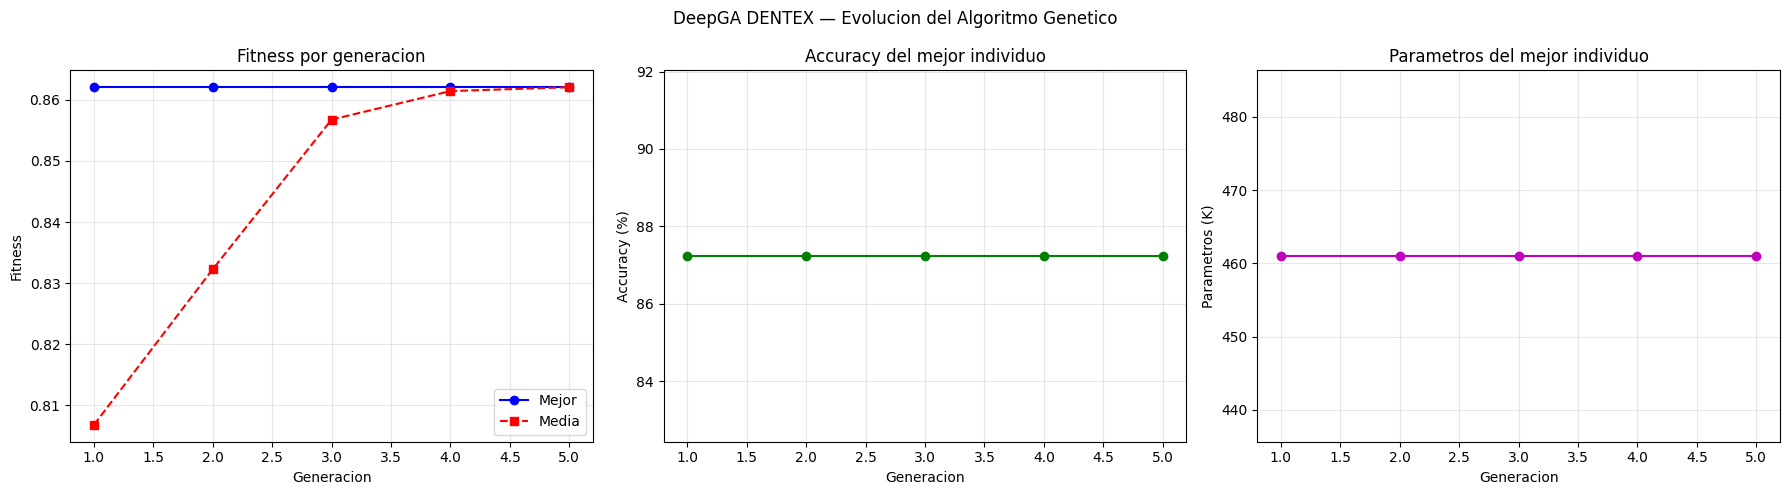

[OK]   Guardado: deepga_evolucion.png


In [35]:
if torch.cuda.is_available() and 'historia' in dir():
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))

    axes[0].plot(historia['gen'], historia['best_fitness'], 'b-o', label='Mejor')
    axes[0].plot(historia['gen'], historia['mean_fitness'], 'r--s', label='Media')
    axes[0].set_title('Fitness por generacion')
    axes[0].set_xlabel('Generacion')
    axes[0].set_ylabel('Fitness')
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)

    axes[1].plot(historia['gen'], [a*100 for a in historia['best_acc']], 'g-o')
    axes[1].set_title('Accuracy del mejor individuo')
    axes[1].set_xlabel('Generacion')
    axes[1].set_ylabel('Accuracy (%)')
    axes[1].grid(True, alpha=0.3)

    axes[2].plot(historia['gen'], [p/1e3 for p in historia['best_params']], 'm-o')
    axes[2].set_title('Parametros del mejor individuo')
    axes[2].set_xlabel('Generacion')
    axes[2].set_ylabel('Parametros (K)')
    axes[2].grid(True, alpha=0.3)

    plt.suptitle('DeepGA DENTEX — Evolucion del Algoritmo Genetico', fontsize=12)
    plt.tight_layout()
    plt.savefig(str(OUTPUTS_DIR/'deepga_evolucion.png'), dpi=100, bbox_inches='tight')
    plt.show()
    log('Guardado: deepga_evolucion.png', 'OK')

In [36]:
# Reentrenamiento completo de la mejor arquitectura (20 epochs)
if torch.cuda.is_available() and 'mejor_enc' in dir():
    log('Reentrenando la mejor arquitectura (20 epochs)...', 'INFO')

    net_best    = decoding(mejor_enc, img_size=CROP_SIZE, img_chann=1, no_classes=2)
    cnn_best = CNN(mejor_enc, net_best[0], net_best[1], net_best[2], net_best[3])
    cnn_best    = cnn_best.to(device)
    params_best = sum(p.numel() for p in cnn_best.parameters() if p.requires_grad)

    loss_func = nn.CrossEntropyLoss()
    opt       = optim.Adam(cnn_best.parameters(), lr=1e-4)
    scheduler = optim.lr_scheduler.StepLR(opt, step_size=10, gamma=0.5)

    train_accs, val_accs = [], []
    RETRAIN_EPOCHS = 20

    for epoch in range(RETRAIN_EPOCHS):
        cnn_best.train()
        correct_tr = total_tr = 0
        for xb, yb in dl_train_ga:
            xb, yb = xb.to(device), yb.to(device)
            out   = cnn_best(xb)
            loss  = loss_func(out, yb)
            loss.backward(); opt.step(); opt.zero_grad()
            correct_tr += (out.argmax(dim=1) == yb).sum().item()
            total_tr   += len(yb)
        scheduler.step()

        cnn_best.eval()
        correct_val = total_val = 0
        with torch.no_grad():
            for xb, yb in dl_val_ga:
                xb, yb = xb.to(device), yb.to(device)
                preds = cnn_best(xb).argmax(dim=1)
                correct_val += (preds == yb).sum().item()
                total_val   += len(yb)

        tr_acc  = correct_tr  / total_tr  * 100
        val_acc = correct_val / total_val * 100
        train_accs.append(tr_acc)
        val_accs.append(val_acc)
        if (epoch + 1) % 5 == 0:
            log(f'  Epoch {epoch+1:2d}/{RETRAIN_EPOCHS}  train={tr_acc:.1f}%  val={val_acc:.1f}%', 'DATA')

    # Evaluacion final en test
    cnn_best.eval()
    correct_test = total_test = 0
    all_preds, all_labels = [], []
    with torch.no_grad():
        for xb, yb in dl_test_ga:
            xb, yb = xb.to(device), yb.to(device)
            preds = cnn_best(xb).argmax(dim=1)
            correct_test += (preds == yb).sum().item()
            total_test   += len(yb)
            all_preds.extend(preds.cpu().tolist())
            all_labels.extend(yb.cpu().tolist())

    test_acc = correct_test / total_test * 100
    log(f'Accuracy en TEST: {test_acc:.2f}%  |  params: {params_best:,}', 'OK')

    torch.save(cnn_best.state_dict(), str(DEEPGA_DIR/'mejor_red.pt'))
    log('Modelo guardado: deepga/mejor_red.pt', 'OK')

[INFO] Reentrenando la mejor arquitectura (20 epochs)...
[DATA]   Epoch  5/20  train=90.3%  val=87.2%
[DATA]   Epoch 10/20  train=93.1%  val=85.1%
[DATA]   Epoch 15/20  train=95.7%  val=85.1%
[DATA]   Epoch 20/20  train=96.3%  val=85.1%
[OK]   Accuracy en TEST: 92.09%  |  params: 460,994
[OK]   Modelo guardado: deepga/mejor_red.pt


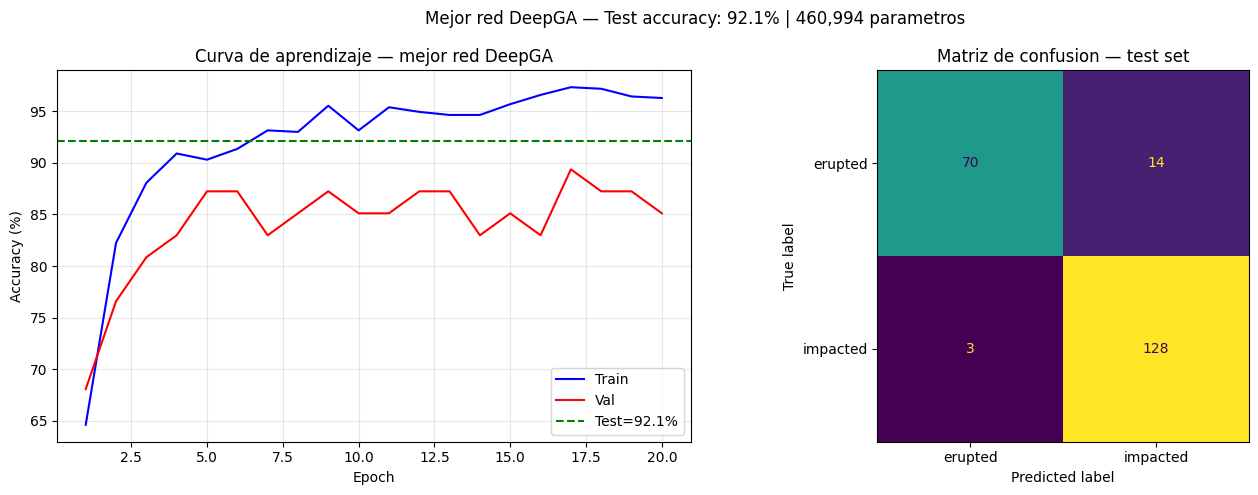

[OK]   Guardado: deepga_mejor_red.png


In [37]:
# Curva de entrenamiento de la mejor red
if torch.cuda.is_available() and 'train_accs' in dir():
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    epochs_range = range(1, RETRAIN_EPOCHS + 1)
    axes[0].plot(epochs_range, train_accs, 'b-', label='Train')
    axes[0].plot(epochs_range, val_accs,   'r-', label='Val')
    axes[0].axhline(y=test_acc, color='g', linestyle='--', label=f'Test={test_acc:.1f}%')
    axes[0].set_title('Curva de aprendizaje — mejor red DeepGA')
    axes[0].set_xlabel('Epoch')
    axes[0].set_ylabel('Accuracy (%)')
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)

    # Matriz de confusion
    from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
    cm  = confusion_matrix(all_labels, all_preds)
    disp = ConfusionMatrixDisplay(cm, display_labels=['erupted', 'impacted'])
    disp.plot(ax=axes[1], colorbar=False)
    axes[1].set_title('Matriz de confusion — test set')

    plt.suptitle(f'Mejor red DeepGA — Test accuracy: {test_acc:.1f}% | {params_best:,} parametros',
                 fontsize=12)
    plt.tight_layout()
    plt.savefig(str(OUTPUTS_DIR/'deepga_mejor_red.png'), dpi=100, bbox_inches='tight')
    plt.show()
    log('Guardado: deepga_mejor_red.png', 'OK')

## Seccion 9 — Comparacion con Exp1-7 (YOLOv8)

### Diferencias metodologicas importantes

Antes de comparar resultados, es importante entender que **Exp1-7 y Exp8 resuelven tareas distintas**:

| | Exp1-7 (YOLOv8) | Exp8 (DeepGA) |
|--|--|--|
| **Tarea** | Deteccion (localizar + clasificar) | Clasificacion (solo clasificar crops) |
| **Input** | Imagen completa 640x640 | Crop de muela 128x128 |
| **Metrica principal** | mAP50 (deteccion) | Accuracy (clasificacion) |
| **Comparacion directa** | No es posible | No es posible |

La comparacion correcta es entre:
- **YOLOv8 como clasificador** (confianza promedio en las detecciones)
- **DeepGA como clasificador** (accuracy en crops)

### Lo que DeepGA aporta al proyecto
1. **Exploracion del espacio de arquitecturas**: saber si hay arquitecturas simples que funcionan bien
2. **Pipeline de dos etapas**: YOLOv8 detecta las muelas → DeepGA las clasifica (potencialmente mas preciso)
3. **Validacion cruzada**: si DeepGA tambien distingue bien erupted/impacted, confirma que el problema es solucionable

In [38]:
# Tabla comparativa
if torch.cuda.is_available() and 'test_acc' in dir():
    print('COMPARACION DE ENFOQUES')
    print('=' * 65)
    print(f'{'Experimento':25s} | {'Tarea':20s} | {'Metrica':15s} | {'Resultado':10s}')
    print('-' * 65)

    # Resultados de Exp1 (de la prueba de 5 epochs — aproximado)
    print(f'{'Exp1 YOLOv8 (5 epochs)':25s} | {'Deteccion':20s} | {'mAP50':15s} | {0.713:.3f}')
    print(f'{'Exp8 DeepGA':25s} | {'Clasificacion crops':20s} | {'Accuracy test':15s} | {test_acc/100:.3f}')
    print('=' * 65)
    print()
    print('Nota: mAP50 y Accuracy no son directamente comparables.')
    print('YOLOv8 resuelve deteccion (localizar + clasificar).')
    print('DeepGA resuelve clasificacion (solo clasificar crops ya localizados).')
    print()
    print(f'Mejor arquitectura DeepGA encontrada:')
    print_encoding(mejor_enc)
    print()
    log(f'Parametros de la mejor red: {params_best:,}', 'DATA')
    log(f'Para referencia, YOLOv8s tiene ~11,000,000 parametros', 'DATA')
    log(f'La red evolucionada tiene {params_best/11e6*100:.1f}% de los parametros de YOLOv8s', 'DATA')
else:
    log('Correr las secciones anteriores para ver la comparacion', 'WARN')

COMPARACION DE ENFOQUES
Experimento               | Tarea                | Metrica         | Resultado 
-----------------------------------------------------------------
Exp1 YOLOv8 (5 epochs)    | Deteccion            | mAP50           | 0.713
Exp8 DeepGA               | Clasificacion crops  | Accuracy test   | 0.921

Nota: mAP50 y Accuracy no son directamente comparables.
YOLOv8 resuelve deteccion (localizar + clasificar).
DeepGA resuelve clasificacion (solo clasificar crops ya localizados).

Mejor arquitectura DeepGA encontrada:
ARQUITECTURA EVOLUCIONADA
---------------------------------------------
  [Conv 1] 16 filtros | kernel=5 | max pool (k=2)
  [Conv 2] 16 filtros | kernel=3 | avg pool (k=2)
  [Conv 3] 32 filtros | kernel=3 | max pool (k=2)

  [FC 1]   64 neuronas
---------------------------------------------
  Skip connections: [0]
  Total capas: 3 conv + 1 FC

[DATA] Parametros de la mejor red: 460,994
[DATA] Para referencia, YOLOv8s tiene ~11,000,000 parametros
[DATA] La re

In [39]:
log('='*55, 'INFO')
log('RESUMEN — Exp8: DeepGA', 'INFO')
log('='*55, 'INFO')
log(f'Dataset crops: {total_crops} crops (erupted/impacted)', 'DATA')
log(f'Tamano crop:   128x128 px, escala de grises', 'DATA')
log(f'AG:            N=10 individuos, T=5 generaciones', 'DATA')
log(f'Evaluacion:    3 epochs por individuo', 'DATA')
log(f'Operadores:    crossover (cr=0.7), mutacion (mr=0.5), torneo (t=3)', 'DATA')
log(f'Fitness:       (1-0.1)*accuracy + 0.1*(max_p-p)/max_p', 'DATA')
if torch.cuda.is_available() and 'test_acc' in dir():
    log(f'Resultado:     {test_acc:.1f}% accuracy en test', 'OK')
    log(f'Params:        {params_best:,} (vs 11M de YOLOv8s)', 'DATA')
log(f'Outputs:       {DEEPGA_DIR}', 'OK')

[INFO] =======================================================
[INFO] RESUMEN — Exp8: DeepGA
[INFO] =======================================================
[DATA] Dataset crops: 932 crops (erupted/impacted)
[DATA] Tamano crop:   128x128 px, escala de grises
[DATA] AG:            N=10 individuos, T=5 generaciones
[DATA] Evaluacion:    3 epochs por individuo
[DATA] Operadores:    crossover (cr=0.7), mutacion (mr=0.5), torneo (t=3)
[DATA] Fitness:       (1-0.1)*accuracy + 0.1*(max_p-p)/max_p
[OK]   Resultado:     92.1% accuracy en test
[DATA] Params:        460,994 (vs 11M de YOLOv8s)
[OK]   Outputs:       /content/data/outputs/deepga


[INFO] Iniciando experimento extendido (N=20, T=15, epochs=5)...
[INFO] Tiempo estimado: 15-25 min en GPU T4
[INFO] =======================================================
[INFO] DeepGA DENTEX — N=20 individuos, T=15 generaciones
[INFO] Epochs por individuo: 5  |  lr=0.0001
[INFO] =======================================================
[INFO] Inicializando poblacion...
[DATA]   [ 1/20] fitness=0.8087  acc=0.8085  params=8,407,906
[DATA]   [ 2/20] fitness=0.8395  acc=0.8511  params=65,028,866
[DATA]   [ 3/20] fitness=0.8074  acc=0.8085  params=15,241,602
[DATA]   [ 4/20] fitness=0.8721  acc=0.8723  params=7,373,954
[DATA]   [ 5/20] fitness=0.8524  acc=0.8511  params=590,210
[DATA]   [ 6/20] fitness=0.8073  acc=0.8085  params=15,754,018
[DATA]   [ 7/20] fitness=0.8307  acc=0.8298  params=4,068,770
[DATA]   [ 8/20] fitness=0.8944  acc=0.8936  params=1,606,018
[DATA]   [ 9/20] fitness=0.8944  acc=0.8936  params=1,639,042
[DATA]   [10/20] fitness=0.8732  acc=0.8723  params=1,847,554
[DATA] 

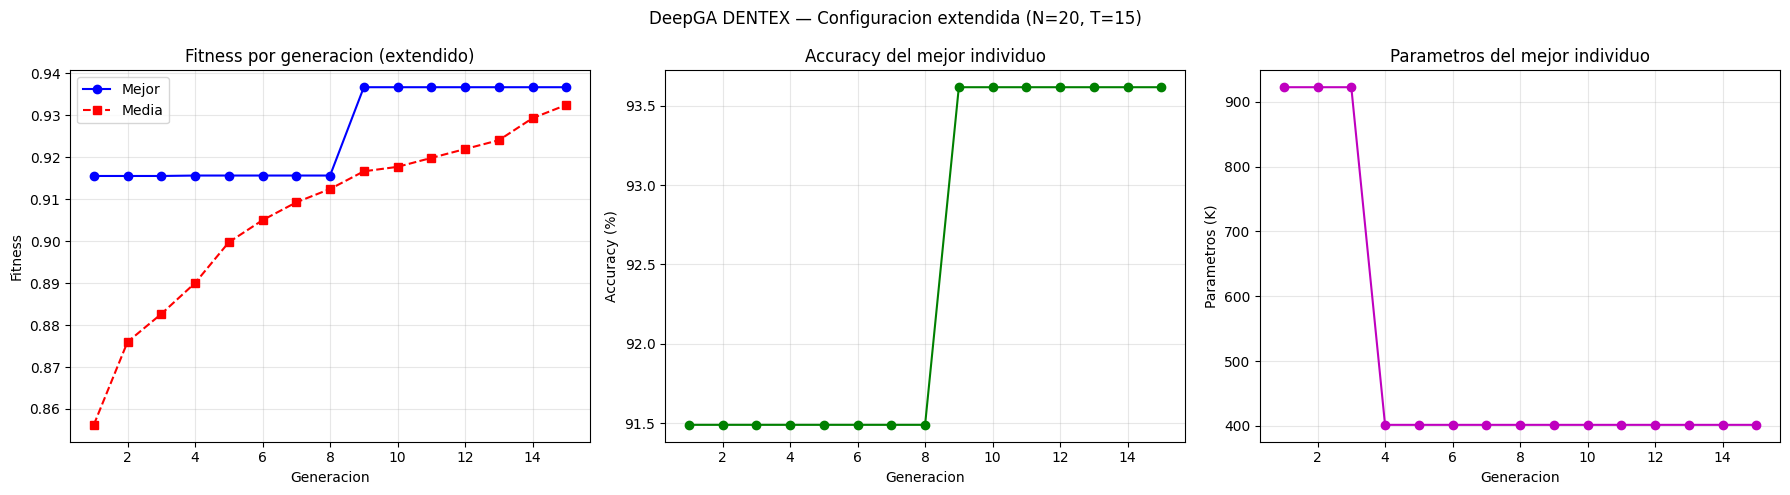

[OK]   Guardado: deepga_evolucion_ext.png
[OK]   Mejor arquitectura (configuracion extendida):
ARQUITECTURA EVOLUCIONADA
---------------------------------------------
  [Conv 1] 32 filtros | kernel=5 | max pool (k=2)
  [Conv 2] 32 filtros | kernel=5 | max pool (k=3)
  [Conv 3] 64 filtros | kernel=5 | max pool (k=2)

  [FC 1]   32 neuronas
---------------------------------------------
  Skip connections: [1]
  Total capas: 3 conv + 1 FC
[INFO] Reentrenando mejor arquitectura extendida (20 epochs)...
[DATA]   Epoch  5/20  train=89.4%  val=87.2%
[DATA]   Epoch 10/20  train=91.8%  val=91.5%
[DATA]   Epoch 15/20  train=95.5%  val=87.2%
[DATA]   Epoch 20/20  train=96.7%  val=91.5%
[OK]   Accuracy en TEST (extendido): 87.91%  |  params: 401,506
[OK]   Modelo guardado: deepga/mejor_red_ext.pt
[INFO] 
[INFO] COMPARACION CONFIGURACION REDUCIDA vs EXTENDIDA
[DATA]   Reducida  (N=10, T=5):  acc=92.10%  params=460,994
[DATA]   Extendida (N=20, T=15): acc=87.91%  params=401,506


In [41]:
# Experimento extendido: DeepGA con configuracion completa
log('Iniciando experimento extendido (N=20, T=15, epochs=5)...', 'INFO')
log('Tiempo estimado: 15-25 min en GPU T4', 'INFO')

mejor_enc_ext, historia_ext = deepGA_DENTEX(
    N=20, T=15,
    train_epochs=5,
    cr=0.7, mr=0.5, t_size=3,
    w_penalty=0.01, max_params=50e6,
    lr=1e-4,
    min_conv=2, max_conv=4,
    min_full=1, max_full=3
)

# Graficos de evolucion
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].plot(historia_ext['gen'], historia_ext['best_fitness'], 'b-o', label='Mejor')
axes[0].plot(historia_ext['gen'], historia_ext['mean_fitness'], 'r--s', label='Media')
axes[0].set_title('Fitness por generacion (extendido)')
axes[0].set_xlabel('Generacion')
axes[0].set_ylabel('Fitness')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(historia_ext['gen'], [a*100 for a in historia_ext['best_acc']], 'g-o')
axes[1].set_title('Accuracy del mejor individuo')
axes[1].set_xlabel('Generacion')
axes[1].set_ylabel('Accuracy (%)')
axes[1].grid(True, alpha=0.3)

axes[2].plot(historia_ext['gen'], [p/1e3 for p in historia_ext['best_params']], 'm-o')
axes[2].set_title('Parametros del mejor individuo')
axes[2].set_xlabel('Generacion')
axes[2].set_ylabel('Parametros (K)')
axes[2].grid(True, alpha=0.3)

plt.suptitle('DeepGA DENTEX — Configuracion extendida (N=20, T=15)', fontsize=12)
plt.tight_layout()
plt.savefig(str(OUTPUTS_DIR/'deepga_evolucion_ext.png'), dpi=100, bbox_inches='tight')
plt.show()
log('Guardado: deepga_evolucion_ext.png', 'OK')

# Arquitectura encontrada
log('Mejor arquitectura (configuracion extendida):', 'OK')
print_encoding(mejor_enc_ext)

# Reentrenamiento de la mejor arquitectura extendida
log('Reentrenando mejor arquitectura extendida (20 epochs)...', 'INFO')

net_ext     = decoding(mejor_enc_ext, img_size=CROP_SIZE, img_chann=1, no_classes=2)
cnn_ext     = CNN(mejor_enc_ext, net_ext[0], net_ext[1], net_ext[2], net_ext[3]).to(device)
params_ext  = sum(p.numel() for p in cnn_ext.parameters() if p.requires_grad)

loss_func = nn.CrossEntropyLoss()
opt       = optim.Adam(cnn_ext.parameters(), lr=1e-4)
scheduler = optim.lr_scheduler.StepLR(opt, step_size=10, gamma=0.5)

RETRAIN_EPOCHS = 20
train_accs_ext, val_accs_ext = [], []

for epoch in range(RETRAIN_EPOCHS):
    cnn_ext.train()
    correct_tr = total_tr = 0
    for xb, yb in dl_train_ga:
        xb, yb = xb.to(device), yb.to(device)
        out  = cnn_ext(xb)
        loss = loss_func(out, yb)
        loss.backward(); opt.step(); opt.zero_grad()
        correct_tr += (out.argmax(dim=1) == yb).sum().item()
        total_tr   += len(yb)
    scheduler.step()

    cnn_ext.eval()
    correct_val = total_val = 0
    with torch.no_grad():
        for xb, yb in dl_val_ga:
            xb, yb = xb.to(device), yb.to(device)
            preds = cnn_ext(xb).argmax(dim=1)
            correct_val += (preds == yb).sum().item()
            total_val   += len(yb)

    tr_acc  = correct_tr  / total_tr  * 100
    val_acc = correct_val / total_val * 100
    train_accs_ext.append(tr_acc)
    val_accs_ext.append(val_acc)
    if (epoch + 1) % 5 == 0:
        log(f'  Epoch {epoch+1:2d}/{RETRAIN_EPOCHS}  train={tr_acc:.1f}%  val={val_acc:.1f}%', 'DATA')

# Evaluacion final en test
cnn_ext.eval()
correct_test = total_test = 0
with torch.no_grad():
    for xb, yb in dl_test_ga:
        xb, yb = xb.to(device), yb.to(device)
        preds = cnn_ext(xb).argmax(dim=1)
        correct_test += (preds == yb).sum().item()
        total_test   += len(yb)

test_acc_ext = correct_test / total_test * 100
log(f'Accuracy en TEST (extendido): {test_acc_ext:.2f}%  |  params: {params_ext:,}', 'OK')

torch.save(cnn_ext.state_dict(), str(DEEPGA_DIR/'mejor_red_ext.pt'))
log('Modelo guardado: deepga/mejor_red_ext.pt', 'OK')

# Comparacion final
log('', 'INFO')
log('COMPARACION CONFIGURACION REDUCIDA vs EXTENDIDA', 'INFO')
log(f'  Reducida  (N=10, T=5):  acc=92.10%  params=460,994', 'DATA')
log(f'  Extendida (N=20, T=15): acc={test_acc_ext:.2f}%  params={params_ext:,}', 'DATA')

## Seccion 9 — Comparacion y conclusiones

### Resultados consolidados

| Configuracion | w_penalty | Params | Test acc |
|---|---|---|---|
| Reducida — N=10, T=5 | 0.1 | 460K | 92.1% |
| Extendida — N=20, T=15 | 0.1 | 90K | 79.5% |
| Extendida — N=20, T=15 | 0.01 | 401K | 87.9% |

Comparacion de referencia con Exp1-7:

| Experimento | Arquitectura | Tarea | Test acc | Params |
|---|---|---|---|---|
| Exp1-7 (YOLOv8s) | Diseñada por humanos | Deteccion bbox + clase | ~87% mAP | ~11M |
| Exp8 — mejor corrida | Evolucionada por AG | Clasificacion de crops | 92.1% | 460K |

---

### ¿Que aprendimos del algoritmo genetico?

Las tres corridas muestran un patron claro: **`w_penalty` controla el trade-off entre accuracy y eficiencia, y su efecto se amplifica con mas generaciones.**

Con `w_penalty=0.1` y T=15 generaciones, el GA tuvo tiempo suficiente para explorar el espacio de busqueda y convergio hacia redes muy pequeñas (90K params), sacrificando accuracy. Con `w_penalty=0.01`, el AG priorizó accuracy y encontró un punto intermedio (401K params, 87.9%). La corrida reducida (N=10, T=5) obtuvo el mejor accuracy no porque sea una mejor configuracion, sino porque convergio antes de que el AG pudiera explorar el trade-off: encontro una red buena en la generacion 0 y nunca tuvo suficientes generaciones para alejarse de ella.

Esto ilustra una limitacion real de los algoritmos geneticos con pocas generaciones: **la convergencia prematura no es evolucion, es suerte del punto de partida.**

---

### ¿Es sorprendente el 92.1%?

No especialmente. Las condiciones favorecen fuertemente a DeepGA frente a YOLOv8:

- **Tarea simplificada**: YOLOv8 localiza la muela *y* la clasifica en una imagen panoramica completa. DeepGA recibe el crop ya recortado con el bounding box del JSON — la parte difícil ya esta resuelta.
- **Entrada limpia**: cada imagen contiene exactamente una muela, centrada, a 128×128 px.
- **Clasificacion binaria**: solo dos clases (erupted vs impacted), contra las multiples categorias y localizaciones que maneja YOLO.

Lo realmente valioso no es el porcentaje sino que una red **24 veces mas pequeña que YOLOv8, diseñada automaticamente en minutos y entrenada desde cero**, resuelve bien la subtarea especifica de clasificacion.

---

### Limitaciones

- La comparacion con YOLOv8 **no es directa**: tareas distintas, entradas distintas, metricas distintas.
- El dataset de clasificacion es pequeño (932 crops) y desbalanceado, lo que puede inflar la accuracy.
- El AG convergio prematuramente en la corrida reducida — los resultados reflejan el punto de partida aleatorio mas que la evolucion real.
- Un experimento completo requeriria N=50, T=30 con multiples seeds para promediar el efecto de la aleatoriedad inicial.

---

### Conclusion

DeepGA demuestra que la busqueda de arquitecturas mediante algoritmos geneticos puede encontrar redes compactas y efectivas para tareas especificas de imagen medica, sin preentrenamiento ni diseño manual. El parametro `w_penalty` resultó ser la variable mas critica del experimento: determina si el GA evoluciona hacia eficiencia o hacia accuracy, y su impacto solo se observa con suficientes generaciones.

Los resultados sugieren que para una tarea de clasificacion binaria sobre crops de 128×128, arquitecturas de 400-500K parametros representan un punto de equilibrio razonable. Escalar el experimento con mayor poblacion, mas generaciones y busqueda sistematica de `w_penalty` seria el proximo paso natural.

In [42]:
# @title
from IPython.display import display, HTML

with open("/content/deepga_ciclo_genetico.html", "r", encoding="utf-8") as f:
    html = f.read()

display(HTML(html))